In [1]:
# Install necessary libraries for this phase
%pip install seaborn scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset from Phase 1
try:
    df = pd.read_csv('data/raw/master_dataset_real.csv')
    print(f"✅ Data Loaded Successfully. Shape: {df.shape}")
    print("\n--- First 5 Rows ---")
    display(df.head())
except FileNotFoundError:
    print("❌ Error: 'master_dataset_real.csv' not found. Please re-run Phase 1.")

✅ Data Loaded Successfully. Shape: (4976, 11)

--- First 5 Rows ---


,latitude,longitude,acq_date,frp,fire_detected,time,interval,temperature_2m,relative_humidity_2m,wind_speed_10m,soil_moisture_0_to_7cm
0,8.96572,77.00488,2026-01-27,0.47,1,2026-01-28T18:00,900,25.4,84,2.2,NaN
1,8.05651,81.23756,2026-01-27,0.42,1,2026-01-28T18:00,900,23.6,82,1.0,NaN
2,28.22190,95.76344,2026-01-27,0.69,1,2026-01-28T18:00,900,18.7,42,8.8,NaN
3,28.22356,95.76181,2026-01-27,0.69,1,2026-01-28T18:00,900,18.4,42,8.8,NaN
4,27.85977,96.32926,2026-01-27,1.25,1,2026-01-28T18:00,900,13.1,70,3.1,NaN


In [3]:
# 1. Parse Dates
df['acq_date'] = pd.to_datetime(df['acq_date'])
df['month'] = df['acq_date'].dt.month

# 2. Handle Time (Safety Check)
# We only try to extract hours if the column actually exists
if 'acq_time' in df.columns:
    print("Processing time features...")
    df['acq_time'] = df['acq_time'].fillna(0).astype(int)
    df['hour'] = df['acq_time'] // 100
    df['is_day'] = df['hour'].apply(lambda x: 1 if 6 <= x <= 18 else 0)
    drop_cols = ['acq_date', 'acq_time', 'dt_utc', 'frp']
else:
    print("⚠️ 'acq_time' column missing. Skipping Hour/Day features (this is fine).")
    drop_cols = ['acq_date', 'dt_utc', 'frp']

# 3. Drop Unused & Leakage Columns
# We use list comprehension to safely drop only columns that exist
cols_to_drop = [c for c in drop_cols if c in df.columns]
df_clean = df.drop(columns=cols_to_drop)

print("\n✅ Feature Engineering Complete.")
print(f"Final Features used for AI: {list(df_clean.columns)}")
display(df_clean.head())

⚠️ 'acq_time' column missing. Skipping Hour/Day features (this is fine).

✅ Feature Engineering Complete.
Final Features used for AI: ['latitude', 'longitude', 'fire_detected', 'time', 'interval', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'soil_moisture_0_to_7cm', 'month']


,latitude,longitude,fire_detected,time,interval,temperature_2m,relative_humidity_2m,wind_speed_10m,soil_moisture_0_to_7cm,month
0,8.96572,77.00488,1,2026-01-28T18:00,900,25.4,84,2.2,NaN,1
1,8.05651,81.23756,1,2026-01-28T18:00,900,23.6,82,1.0,NaN,1
2,28.22190,95.76344,1,2026-01-28T18:00,900,18.7,42,8.8,NaN,1
3,28.22356,95.76181,1,2026-01-28T18:00,900,18.4,42,8.8,NaN,1
4,27.85977,96.32926,1,2026-01-28T18:00,900,13.1,70,3.1,NaN,1


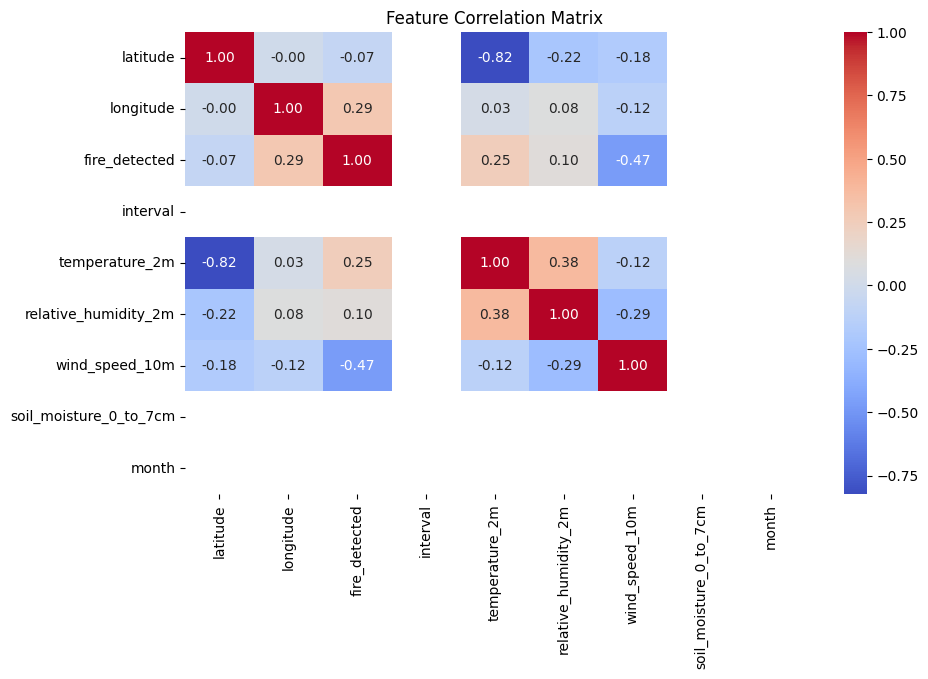

Interpreting the Heatmap:
1. Look at the 'fire_detected' row.
2. RED (Positive) = Factors that HELP fires (e.g., Temperature, Wind).
3. BLUE (Negative) = Factors that STOP fires (e.g., Humidity, Moisture).


In [4]:
plt.figure(figsize=(10, 6))

# Calculate correlation matrix ONLY on numeric columns to prevent errors
corr = df_clean.corr(numeric_only=True)

# Plot heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

print("Interpreting the Heatmap:")
print("1. Look at the 'fire_detected' row.")
print("2. RED (Positive) = Factors that HELP fires (e.g., Temperature, Wind).")
print("3. BLUE (Negative) = Factors that STOP fires (e.g., Humidity, Moisture).")

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Define Features (X) and Target (y)
X = df_clean.drop('fire_detected', axis=1)
# Ensure we only select numeric columns for X to avoid errors in scaling
X = X.select_dtypes(include=[np.number]) 
y = df_clean['fire_detected']

# 2. Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the Data (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Save Processed Data
np.save('data/processed/X_train.npy', X_train_scaled)
np.save('data/processed/X_test.npy', X_test_scaled)
np.save('data/processed/y_train.npy', y_train)
np.save('data/processed/y_test.npy', y_test)

print("✅ Phase 2 Complete!")
print(f"Training Data: {X_train_scaled.shape[0]} rows")
print(f"Testing Data:  {X_test_scaled.shape[0]} rows")
print("Files saved to 'data/processed/' folder.")

✅ Phase 2 Complete!
Training Data: 3980 rows
Testing Data:  996 rows
Files saved to 'data/processed/' folder.


c:\Users\vaast\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\extmath.py:1207: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\vaast\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\extmath.py:1212: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\vaast\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\extmath.py:1236: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count
